In [1]:
import pandas as pd
import numpy as np

from scipy.stats import linregress

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

nav_history = pd.read_csv(
    PROJECT_ROOT /
    "data/processed/clean_nav_history.csv"
)

fund_master = pd.read_csv(
    PROJECT_ROOT /
    "data/raw/01_fund_master.csv"
)

benchmark = pd.read_csv(
    PROJECT_ROOT /
    "data/raw/10_benchmark_indices.csv"
)

In [2]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

nav_history = nav_history.sort_values(
    ["amfi_code","date"]
)

nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


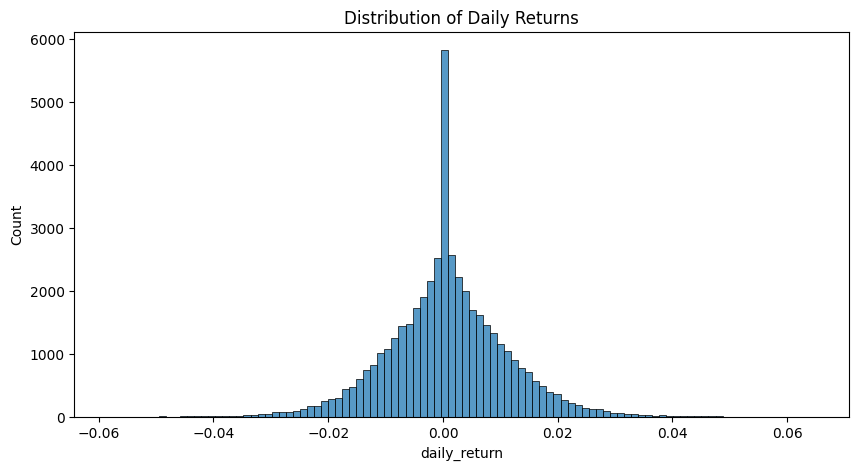

In [3]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav_history["daily_return"],
    bins=100
)

plt.title(
    "Distribution of Daily Returns"
)

plt.show()

In [4]:
def calculate_cagr(group):

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    years = (
        len(group) / 252
    )

    return (
        (end_nav / start_nav)
        ** (1/years)
        - 1
    )

In [5]:
cagr_df = (
    nav_history
    .groupby("amfi_code")
    .apply(calculate_cagr)
    .reset_index()
)

cagr_df.columns = [
    "amfi_code",
    "cagr"
]

cagr_df.head()

/tmp/ipykernel_8645/635010644.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_cagr)


,amfi_code,cagr
0,100016,0.025412
1,100025,0.042948
2,100033,0.288994
3,101206,0.226048
4,101207,0.076433


In [6]:
cagr_df.head()

,amfi_code,cagr
0,100016,0.025412
1,100025,0.042948
2,100033,0.288994
3,101206,0.226048
4,101207,0.076433


In [7]:
RISK_FREE_RATE = 0.065

In [8]:
def calculate_sharpe(group):

    returns = (
        group["daily_return"]
        .dropna()
    )

    annual_return = (
        returns.mean() * 252
    )

    annual_volatility = (
        returns.std() * np.sqrt(252)
    )

    if annual_volatility == 0:
        return np.nan

    sharpe = (
        (annual_return - RISK_FREE_RATE)
        / annual_volatility
    )

    return sharpe

In [9]:
sharpe_df = (
    nav_history
    .groupby("amfi_code")
    .apply(calculate_sharpe)
    .reset_index()
)

sharpe_df.columns = [
    "amfi_code",
    "sharpe_ratio"
]

sharpe_df.head()

/tmp/ipykernel_8645/1123649514.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_sharpe)


,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [10]:
def calculate_sortino(group):

    returns = (
        group["daily_return"]
        .dropna()
    )

    annual_return = (
        returns.mean() * 252
    )

    downside_returns = (
        returns[returns < 0]
    )

    downside_std = (
        downside_returns.std()
        * np.sqrt(252)
    )

    if downside_std == 0:
        return np.nan

    return (
        (annual_return - RISK_FREE_RATE)
        / downside_std
    )

In [11]:
sortino_df = (
    nav_history
    .groupby("amfi_code")
    .apply(calculate_sortino)
    .reset_index()
)

sortino_df.columns = [
    "amfi_code",
    "sortino_ratio"
]

/tmp/ipykernel_8645/2269693048.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_sortino)


In [12]:
def calculate_max_drawdown(group):

    nav = group["nav"]

    running_max = nav.cummax()

    drawdown = (
        nav - running_max
    ) / running_max

    return drawdown.min()

In [13]:
mdd_df = (
    nav_history
    .groupby("amfi_code")
    .apply(calculate_max_drawdown)
    .reset_index()
)

mdd_df.columns = [
    "amfi_code",
    "max_drawdown"
]

/tmp/ipykernel_8645/1207170037.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_max_drawdown)


In [14]:
sharpe_df.head()

sortino_df.head()

mdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [15]:
print(sharpe_df.shape)
print(sortino_df.shape)

sharpe_df.head()
sortino_df.head()

(40, 2)
(40, 2)


,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [16]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [17]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [18]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [19]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [20]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [21]:
from scipy.stats import linregress

results = []

In [23]:
print(nav_history["date"].dtype)
print(nifty100["date"].dtype)

datetime64[ns]
object


In [24]:
nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

In [25]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [27]:
print(nifty100["date"].dtype)

datetime64[ns]


In [28]:
print(nav_history["date"].dtype)
print(nifty100["date"].dtype)

datetime64[ns]
datetime64[ns]


In [30]:
nifty100.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [31]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values(
    "date"
)

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

print(nifty100.columns)

nifty100.head()

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='object')


,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [32]:
results = []

for amfi_code, group in nav_history.groupby("amfi_code"):

    merged = group.merge(
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    results.append([
        amfi_code,
        intercept * 252,   # Alpha
        slope              # Beta
    ])

In [33]:
alpha_beta_df = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

print(alpha_beta_df.shape)

alpha_beta_df.head()

(40, 3)


,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [34]:
alpha_beta_df.to_csv(
    PROJECT_ROOT / "reports" / "alpha_beta.csv",
    index=False
)

In [35]:
alpha_beta_df.shape
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [36]:
scorecard = (
    cagr_df
    .merge(sharpe_df, on="amfi_code")
    .merge(sortino_df, on="amfi_code")
    .merge(mdd_df, on="amfi_code")
    .merge(alpha_beta_df, on="amfi_code")
)

In [37]:
scorecard = scorecard.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "expense_ratio_pct"
        ]
    ],
    on="amfi_code"
)

In [38]:
scorecard["cagr_rank"] = (
    scorecard["cagr"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

In [39]:
scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)

In [40]:
scorecard["final_score"] = (
      scorecard["cagr_rank"] * 0.30
    + scorecard["sharpe_rank"] * 0.25
    + scorecard["alpha_rank"] * 0.20
    + scorecard["expense_rank"] * 0.15
    + scorecard["drawdown_rank"] * 0.10
)

In [41]:
scorecard = scorecard.sort_values(
    "final_score"
)

scorecard["overall_rank"] = range(
    1,
    len(scorecard)+1
)

scorecard.head(10)

,amfi_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown,alpha,beta,scheme_name,fund_house,expense_ratio_pct,cagr_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,final_score,overall_rank
25,120505,0.314811,1.180101,2.029353,-0.181885,0.292636,0.000549,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,1.36,1.0,5.0,3.0,15.0,25.0,6.900,1
34,148567,0.297120,1.448291,2.385644,-0.112657,0.269838,0.023684,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.46,5.0,1.0,7.0,23.0,8.0,7.400,2
30,120843,0.296483,1.306744,2.364320,-0.129740,0.273305,-0.022830,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,1.45,6.0,2.0,5.0,22.0,13.0,7.900,3
2,100033,0.288994,1.093699,1.829134,-0.162172,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,1.38,7.0,7.0,6.0,17.0,20.0,9.600,4
36,148569,0.306432,1.234930,2.146914,-0.163967,0.282704,0.018134,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,1.60,4.0,3.0,4.0,36.5,21.0,10.325,5
21,119598,0.310957,0.945308,1.675317,-0.287060,0.303370,-0.023196,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,1.43,2.0,14.0,1.0,21.0,36.0,11.050,6
24,120504,0.223720,1.026524,1.805294,-0.125883,0.211948,0.016232,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,0.80,13.0,10.0,13.0,12.0,12.0,12.000,7
20,119552,0.206770,0.953279,1.609776,-0.118035,0.198686,-0.026159,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,0.66,15.0,12.0,15.0,4.0,11.0,12.200,8
39,149324,0.309658,0.949796,1.619793,-0.311719,0.300579,0.011455,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,1.52,3.0,13.0,2.0,26.5,37.0,12.225,9
19,119551,0.247726,1.208267,2.140267,-0.150124,0.232010,-0.031751,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,1.54,10.0,4.0,10.0,30.5,17.0,12.275,10


In [42]:
scorecard.to_csv(
    PROJECT_ROOT /
    "reports/fund_scorecard.csv",
    index=False
)

In [43]:
top5 = (
    scorecard
    .head(5)["amfi_code"]
    .tolist()
)

In [44]:
comparison = nav_history[
    nav_history["amfi_code"]
    .isin(top5)
].copy()

comparison["cum_return"] = (
    comparison
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: (1 + x.fillna(0)).cumprod()
    )
)

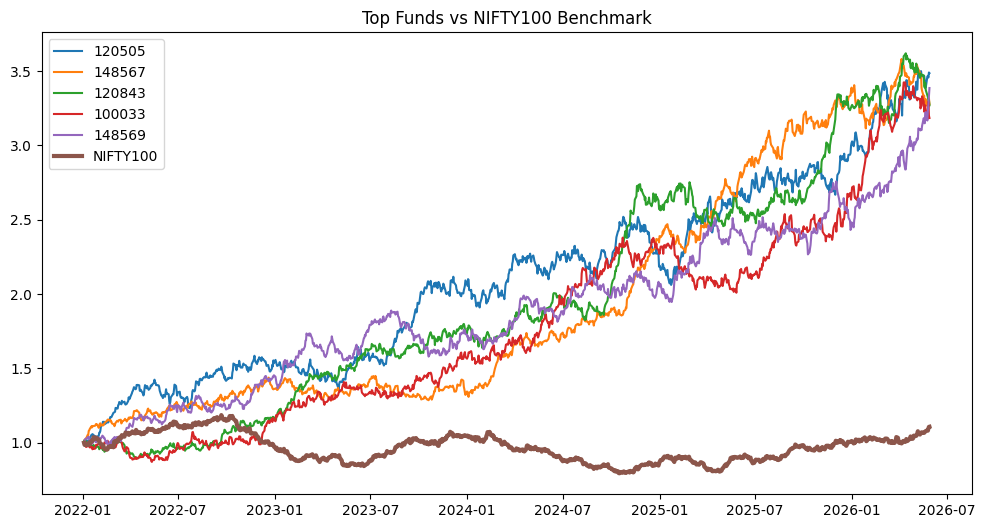

In [45]:
plt.figure(figsize=(12,6))

for fund in top5:

    temp = comparison[
        comparison["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["cum_return"],
        label=str(fund)
    )

benchmark_plot = nifty100.copy()

benchmark_plot["cum_return"] = (
    (1 + benchmark_plot["benchmark_return"].fillna(0))
    .cumprod()
)

plt.plot(
    benchmark_plot["date"],
    benchmark_plot["cum_return"],
    linewidth=3,
    label="NIFTY100"
)

plt.legend()

plt.title(
    "Top Funds vs NIFTY100 Benchmark"
)

plt.savefig(
    PROJECT_ROOT /
    "charts/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [46]:
scorecard[
    [
        "overall_rank",
        "scheme_name",
        "final_score"
    ]
].head()

,overall_rank,scheme_name,final_score
25,1,ICICI Pru Midcap Fund - Regular - Growth,6.900
34,2,Mirae Asset Large Cap Fund - Regular - Growth,7.400
30,3,Kotak Flexicap Fund - Regular - Growth,7.900
2,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,9.600
36,5,Mirae Asset Tax Saver Fund - Regular - Growth,10.325
